In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import linalg as ln
from scipy import sparse
from scipy.sparse import linalg as sln


We move on to 2D, solving heat conduction on a plate. 

Governing equation: $\frac{\partial u}{\partial t} = \kappa(\frac{\partial^2 u}{\partial x^2}+\frac{\partial^2 u}{\partial y^2})$

Using uniform mesh sizes $h$ in a Cartesian grid, we first proceed with a uniform rectangular domain with length $L$ and height $H$.

Denote index $i, j$ subscript for steps in space, $\delta$ superscript for steps in time.

$\frac{\partial u}{\partial t} \approx \frac{1}{\Delta t}(u_{i,j} ^{(\delta + 1)}- u_{i,j} ^{(\delta)})$ is the forward difference in time.

$\frac{\partial^2 u}{\partial x^2} \approx \frac{1}{h^2}(u_{i+1,j} ^{(\delta)} + u_{i-1,j} ^{(\delta)} + u_{i,j+1} ^{(\delta)} + u_{i,j-1} ^{(\delta)} - 4u_{i,j} ^{(\delta)})$ 

If our mesh is anisotropic, i.e. the mesh size in x and y differ, then the difference equation must be: 

$\kappa\frac{\partial^2 u}{\partial x^2} \approx \frac{\kappa}{\Delta x^2}(u_{i+1,j} ^{(\delta)} + u_{i-1,j} ^{(\delta)} - 2u_{i,j} ^{(\delta)}) + \frac{\kappa}{\Delta y^2}(u_{i,j+1} ^{(\delta)} + u_{i,j-1} ^{(\delta)} - 2u_{i,j} ^{(\delta)})$ 

is the second order central difference in x and y, using a five-point stencil.

In [43]:
kappa = 0.5

In [ ]:
def heatequation2D(time_span, u0, dt, points_interior, dims, b,f=None):
    t_init, t_end = time_span
    px, py = points_interior
    Lx, Ly = dims
    hx, hy = (Lx/(px+1),Ly/(py+1))

    interior = px*py
    
    t = np.arange(t_init, t_end + dt, dt)
    interval = len(t)

    u0 = np.atleast_1d(u0).astype(float)

    u = np.zeros((interior,interval), dtype = float)
    u[:,0] = u0

    b = b.astype(float)
    if f is None:
        f = np.zeros(interior)
    f = f.astype(float)
    
    #Define the 1D Laplacian in x and y
    Kx = sparse.diags([1,-2,1], [-1,0,1], shape = (px,px))
    Ky = sparse.diags([1,-2,1], [-1,0,1], shape = (py,py))

    Ix = sparse.identity(px)
    Iy = sparse.identity(py)

    #Define the 2D discrete Laplacian using the Kronecker product:
    IyKx = sparse.kron(Iy, Kx) 
    KyIx = sparse.kron(Ky, Ix)

    L = IyKx + KyIx

    I = sparse.identity(interior)

    rx, ry = (kappa * dt / hx**2, kappa * dt / hy**2)

    #Applying the Crank-Nicolson scheme.

    B =  I - 0.5*(rx*IyKx + ry*KyIx)
    B = B.tocsc()
    A =   I + 0.5*(rx*IyKx + ry*KyIx)
    A = A.tocsc()

    solver = sparse.linalg.splu(B)

    for i in range(interval - 1):
        rhs = A @ u[:,i] + dt*(b-f) 
        u[:,i+1] = solver.solve(rhs)
        

    return t, u

In [282]:
def poisson2D(points_interior, dims, b, f=None):
    py, px = points_interior
    Ly, Lx = dims
    hx, hy = (Lx/(px+1),Ly/(py+1))

    interior = px*py

    u = np.zeros(interior, dtype = float)

    b = b.astype(float)

    if f is None:
        f = np.zeros(interior)
    f = f.astype(float)
    
    #Define the 1D Laplacian in x and y
    Kx = sparse.diags([1,-2,1], [-1,0,1], shape = (px,px))
    Ky = sparse.diags([1,-2,1], [-1,0,1], shape = (py,py))

    Ix = sparse.identity(px)
    Iy = sparse.identity(py)

    #Define the 2D discrete Laplacian using the Kronecker product:
    IyKx = sparse.kron(Iy, Kx) 
    KyIx = sparse.kron(Ky, Ix)

    K = IyKx/hx**2 + KyIx/hy**2


    u = sln.spsolve(-K.tocsc(), f + b)
    
    return u

In [209]:
def build_dirichlet_bc(points_interior, dims, bc):

    py, px = points_interior
    Ly, Lx = dims

    hx = Lx/(px+1)
    hy = Ly/(py+1)

    interior = px * py
    b = np.zeros(interior)

    # Interior grid coordinates
    x = np.linspace(hx, Lx-hx, px)
    y = np.linspace(hy, Ly-hy, py)

    # LEFT boundary (x = 0)
    if bc.get("left") is not None:
        vals = bc["left"](y)
        for j in range(py):
            k = 0 + j*px
            b[k] += vals[j] / hx**2

    # RIGHT boundary (x = Lx)
    if bc.get("right") is not None:
        vals = bc["right"](y)
        for j in range(py):
            k = (px-1) + j*px
            b[k] += vals[j] / hx**2

    # BOTTOM boundary (y = 0)
    if bc.get("bottom") is not None:
        vals = bc["bottom"](x)
        for i in range(px):
            k = i + 0*px
            b[k] += vals[i] / hy**2

    # TOP boundary (y = Ly)
    if bc.get("top") is not None:
        vals = bc["top"](x)
        for i in range(px):
            k = i + (py-1)*px
            b[k] += vals[i] / hy**2

    return b


In [328]:
def build_neumann_bc(points_interior, dims, bc):

    py, px = points_interior
    Ly, Lx = dims

    hx = Lx/(px+1)
    hy = Ly/(py+1)

    interior = px * py

    rhs = np.zeros(interior)
    diag = np.zeros(interior)

    x = np.linspace(hx, Lx-hx, px)
    y = np.linspace(hy, Ly-hy, py)

    # LEFT boundary (x=0)
    if bc.get("left") is not None:
        vals = bc["left"](y)
        for j in range(py):
            k = 0 + j*px
            rhs[k] -= vals[j] / hx
            diag[k] += 1/hx**2

    # RIGHT boundary (x=Lx)
    if bc.get("right") is not None:
        vals = bc["right"](y)
        for j in range(py):
            k = (px-1) + j*px
            rhs[k] += vals[j] / hx
            diag[k] += 1/hx**2

    # BOTTOM boundary (y=0)
    if bc.get("bottom") is not None:
        vals = bc["bottom"](x)
        for i in range(px):
            k = i + 0*px
            rhs[k] -= vals[i] / hy
            diag[k] += 1/hy**2

    # TOP boundary (y=Ly)
    if bc.get("top") is not None:
        vals = bc["top"](x)
        for i in range(px):
            k = i + (py-1)*px
            rhs[k] += vals[i] / hy
            diag[k] += 1/hy**2

    return rhs, diag


In [329]:
def poisson2D_neumann(points_interior, dims, bcD = None, bcN = None, f=None):
    py, px = points_interior
    Ly, Lx = dims
    hx, hy = (Lx/(px+1),Ly/(py+1))

    interior = px*py

    u = np.zeros(interior, dtype = float)

    if f is None:
        f = np.zeros(interior)
    f = f.astype(float)

    #Define the 1D Laplacian in x and y
    Kx = sparse.diags([1,-2,1], [-1,0,1], shape = (px,px))
    Ky = sparse.diags([1,-2,1], [-1,0,1], shape = (py,py))

    Ix = sparse.identity(px)
    Iy = sparse.identity(py)

    #Define the 2D discrete Laplacian using the Kronecker product:
    IyKx = sparse.kron(Iy, Kx) 
    KyIx = sparse.kron(Ky, Ix)

    K = IyKx/hx**2 + KyIx/hy**2

    rhs = f.copy()

    if bcD is not None: #Dirichlet imposed
        rhs += bcD

    if bcN is not None: #Neumann imposed
        rhsN, diagN = bcN
        rhs += rhsN
        K = K + sparse.diags(diagN, format = 'csr')

        if bcD is None: #Pure Neumann
            K = K.tolil()
            K[0,:] = 0
            K[0,0] = 1
            rhs[0] = 0
            K = K.tocsc()
            
    if bcD is None and bcN is None:
        raise ValueError("need BCs")

    u = sln.spsolve((-K).tocsc(), rhs)

    return u

In [330]:
#Define grid
px,py = (199, 199)
size = (20, 20)

#Define initial conditions
u0_2d = np.zeros((px,py)) #initiate

    #ring of points initial conditions:
u0_2d[px//2, py//2] = 10
u0_2d[px//4, py//4] = 5
u0_2d[3*px//4, 3*py//4] = 5
u0_2d[px//4, 3*py//4] = 5
u0_2d[3*px//4, py//4] = 5
u0_2d[100, 25] = 5
u0_2d[25, 100] = 5
u0_2d[100, 175] = 5
u0_2d[175, 100] = 5


#The initial condition must be flat to input into the function.
u0_flat = u0_2d.ravel()


b0 = build_dirichlet_bc((px,py), size, bc = {
    "left":   lambda y: 0*y,
    "right":  lambda y: 0*y,
    "bottom": lambda x: 0*x,
    "top":    lambda x: 0*x
})
b1 = build_dirichlet_bc((px,py), size, bc = {
    "left":   lambda y: 0*y+10,
    "right":  lambda y: 0*y,
    "bottom": lambda x: 0*x+10,
    "top":    lambda x: 0*x
})

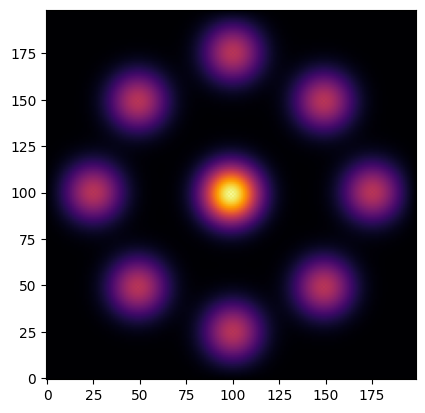

In [331]:
time, sol_flat = heatequation2D((0,10), u0_flat, 0.01, (px,py), size, b = b0)

#indeed, any representation of the grid point values are all flattened 
#before being computed on, and must be restored for plotting.
sol_2d = sol_flat[:, 30].reshape((px,py))
plt.clf()
plt.imshow(sol_2d, origin='lower', cmap = 'inferno')


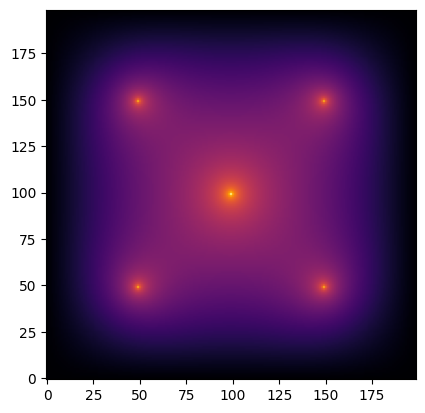

In [332]:
# testing the Poisson solver.

interior = (199,199)
px,py=interior
size = (20,20)

source = np.zeros(interior)
x = np.arange(interior[1])
y = np.arange(interior[0])
#source[:,:] = 10*np.sin(100*y[:,None])

    #ring of points initial conditions:
source[px//2, py//2] = 10
source[px//4, py//4] = 10
source[3*px//4, 3*py//4] = 10
source[px//4, 3*py//4] = 10
source[3*px//4, py//4] = 10

bc1 = build_dirichlet_bc(interior, size, bc = {
    "left":   lambda y: 0*y,
    "right":  lambda y: (y)**2,
    "bottom": lambda x: x**2,
    "top":    lambda x: 0*x
})

bc0 = build_dirichlet_bc(interior, size, bc = {
    "left":   lambda y: 0*y,
    "right":  lambda y: 0*y,
    "bottom": lambda x: 0*x,
    "top":    lambda x: 0*x
})

sol_flat_p = poisson2D(interior, size, f=source.ravel(),
                       b = bc0)
sol_2d = sol_flat_p.reshape(interior)
plt.clf()
plt.imshow(sol_2d, origin='lower', cmap = 'inferno')

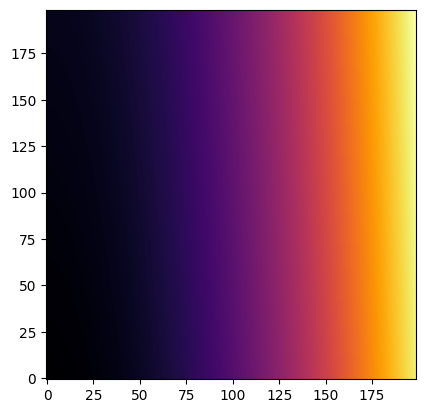

In [333]:
# testing Neumann boundaries, Poisson equation

# testing the Poisson solver.

interior = (199,199)
px,py=interior
size = (20,20)
Lx,Ly = size

source = np.zeros(interior)
x = np.arange(interior[1])
y = np.arange(interior[0])
#source[:,:] = 10*np.sin(100*y[:,None])

    #ring of points initial conditions:
source[px//2, py//2] = 10
source[px//4, py//4] = 10
source[3*px//4, 3*py//4] = 10
source[px//4, 3*py//4] = 10
source[3*px//4, py//4] = 10

no_source = np.zeros(interior)

bcN1 = build_neumann_bc(interior, size, bc = {
    "left":   lambda y: 0*y,
    "right":  lambda y: (y)**2,
    "bottom": lambda x: x**2,
    "top":    lambda x: 0*x
})

bcN0 = build_neumann_bc(interior, size, bc = {
    #"left":   lambda y: 0*y,
    "right":  lambda y: 0*y + Lx*2 ,
    #"bottom": lambda x: 0*x,
    "top":    lambda x: 0*x + 1
})

bcD0 = build_dirichlet_bc(interior, size, bc = {
    "left":  lambda y: y,
    "bottom": lambda x: x**2
})

sol_flat_p = poisson2D_neumann(interior, size, f=(-2*np.ones(interior)).ravel(),
                                bcN = bcN0, bcD = bcD0 )
sol_2d = sol_flat_p.reshape(interior)
plt.clf()
plt.imshow(sol_2d, origin='lower', cmap = 'inferno')

In [334]:
hx = Lx/(px+1)
hy = Ly/(py+1)

x = np.linspace(hx, Lx-hx, px)
y = np.linspace(hy, Ly-hy, py)

X, Y = np.meshgrid(x,y)

u_exact = X**2 + Y

err = np.max(np.abs(sol_2d - u_exact))

print("Max error:", err)

Max error: 1.3422485796697856
